# Elasticity: from the tensor to $B_{pq}(\mathbf n)$

Corrected teaching edition of the MS5033/IC5123 course's **Elastic.ipynb**. Run all cells in order. NumPy and Matplotlib only. New teaching code: GPL-3.0-or-later.

The original notebook's Voigt-to-fourth-order index mapping was incorrect. This edition constructs $C_{ijkl}$ directly, checks shear and tensor symmetries, removes the singular-inverse regularization, and makes the zero-mode assumption explicit. The original course file has not been overwritten.

## What is being calculated?

$$\sigma^{0,p}_{ij}=C_{ijkl}\epsilon^{0,p}_{kl},\quad Q_{ik}=C_{ijkl}n_jn_l,$$
$$B_{pq}=\epsilon^{0,p}:C:\epsilon^{0,q}-(\sigma^{0,p}n)\cdot Q^{-1}(\sigma^{0,q}n).$$

$B_{pq}$ is the **elastic energy kernel**, not the energy or an elastic modulus. Homogeneous stiffness is assumed. Self kernels are nonnegative; a cross kernel may be negative. With the DFT normalized by the number of pixels, the fluctuating energy density is $\tfrac12\sum_{k\ne0,p,q}B_{pq}\hat h_p^*\hat h_q$.

This notebook uses a full **3-D cubic tensor**, sampled at in-plane Fourier normals $n=(\cos\theta,\sin\theta,0)$. The physical eigenstrain's zz component is specified below. In-plane direction labels use [10], [01] and [11]. This is not a plane-stress reduction. The companion two-solid solvers use the 2-D sub-block with zero zz eigenstrain.

The formula applies only at nonzero wavevector. At zero applied mean stress with homogeneous stiffness, $E=\langle\epsilon^0\rangle$ removes the mean energy. At prescribed mean strain, add $\tfrac12(E-\langle\epsilon^0\rangle):C:(E-\langle\epsilon^0\rangle)$. Do not assign a direction to $k=0$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def cubic_tensor(c11, c12, c44):
    """Full 3-D cubic tensor, built directly without ambiguous Voigt mapping."""
    if min(c44, c11-c12, c11+2*c12) <= 0:
        raise ValueError('Cubic stiffness must be positive definite.')
    identity = np.eye(3)
    tensor = np.zeros((3,3,3,3))
    for i in range(3):
        for j in range(3):
            for k in range(3):
                for l in range(3):
                    tensor[i,j,k,l] = (c12*identity[i,j]*identity[k,l]
                        +c44*(identity[i,k]*identity[j,l]+identity[i,l]*identity[j,k]))
                    if i == j == k == l:
                        tensor[i,j,k,l] += c11-c12-2*c44
    return tensor

def energy_kernel(stiffness, eigenstrain_p, eigenstrain_q, direction):
    """Bpq(n), not total energy. direction must be a nonzero 3-vector."""
    direction = np.asarray(direction, dtype=float)
    if direction.shape != (3,) or np.linalg.norm(direction) == 0:
        raise ValueError('Supply a nonzero three-component Fourier direction.')
    normal = direction/np.linalg.norm(direction)
    acoustic = np.einsum('ijkl,j,l->ik', stiffness, normal, normal)
    sigma_p = np.einsum('ijkl,kl->ij', stiffness, eigenstrain_p)
    sigma_q = np.einsum('ijkl,kl->ij', stiffness, eigenstrain_q)
    local_term = np.sum(eigenstrain_p*sigma_q)
    relaxation_term = (sigma_p@normal) @ np.linalg.solve(acoustic, sigma_q@normal)
    return local_term-relaxation_term


## Choose the eigenstrains and elastic constants
Change one source of anisotropy at a time. Here beta and gamma have opposite in-plane dilatational misfits. Set C44=(C11−C12)/2 for isotropic elasticity.

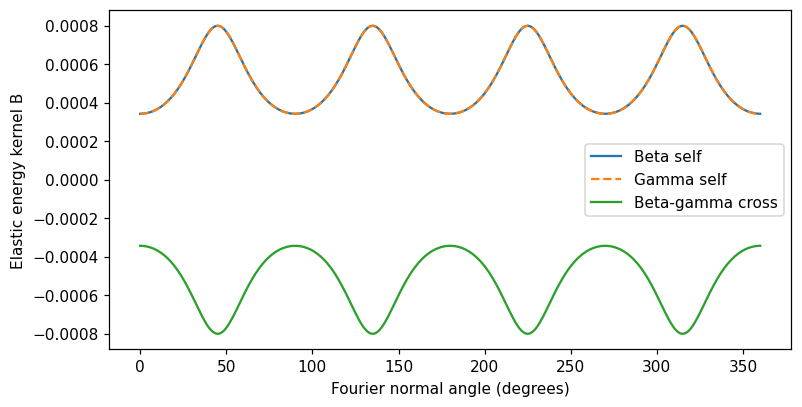

In [2]:
C11, C12, C44 = 7.0, 5.0, 3.0
stiffness = cubic_tensor(C11, C12, C44)
eigenstrain_beta = np.diag([0.01, 0.01, 0.0])
eigenstrain_gamma = -eigenstrain_beta
angles = np.linspace(0, 2*np.pi, 361)
beta_self = []
gamma_self = []
cross = []
for angle in angles:
    normal = [np.cos(angle), np.sin(angle), 0.0]
    beta_self.append(energy_kernel(stiffness, eigenstrain_beta, eigenstrain_beta, normal))
    gamma_self.append(energy_kernel(stiffness, eigenstrain_gamma, eigenstrain_gamma, normal))
    cross.append(energy_kernel(stiffness, eigenstrain_beta, eigenstrain_gamma, normal))
fig, axis = plt.subplots(figsize=(8,4))
axis.plot(np.rad2deg(angles), beta_self, label='Beta self')
axis.plot(np.rad2deg(angles), gamma_self, '--', label='Gamma self')
axis.plot(np.rad2deg(angles), cross, label='Beta-gamma cross')
axis.set(xlabel='Fourier normal angle (degrees)', ylabel='Elastic energy kernel B')
axis.legend()
plt.show()


## Checks that expose the mathematics
The self kernel is nonnegative, reversing one eigenstrain reverses the cross kernel, isotropic in-plane dilatation has a direction-independent kernel, and the shear stress must include the tensor-shear factor of two.

In [3]:
assert np.allclose(stiffness, stiffness.swapaxes(0,1))
assert np.allclose(stiffness, stiffness.swapaxes(2,3))
assert np.allclose(stiffness, stiffness.transpose(2,3,0,1))
shear = np.zeros((3,3)); shear[0,1] = shear[1,0] = 0.02
shear_stress = np.einsum('ijkl,kl->ij', stiffness, shear)
assert np.isclose(shear_stress[0,1], 2*C44*0.02)
assert min(beta_self) >= -1e-12
assert np.allclose(cross, -np.asarray(beta_self))
isotropic = cubic_tensor(4.0, 2.0, 1.0)
in_plane = np.diag([1.0, 1.0, 0.0])
values = [energy_kernel(isotropic, in_plane, in_plane,
    [np.cos(angle),np.sin(angle),0]) for angle in angles]
assert np.allclose(values, 3.0)
assert np.isclose(energy_kernel(stiffness,eigenstrain_beta,eigenstrain_gamma,[1,1,0]),
                  energy_kernel(stiffness,eigenstrain_gamma,eigenstrain_beta,[1,1,0]))
print('Tensor symmetry, shear, isotropy, positivity and cross-sign checks passed.')


Tensor symmetry, shear, isotropy, positivity and cross-sign checks passed.


## Explore and explain

Use $\epsilon^0_\beta=0.01\,\mathrm{diag}(1,t,0)$ and vary $t$. Plot its self kernel again. Compare changing the eigenstrain with changing $C_{44}$. Rotate the eigenstrain by $R\epsilon^0R^T$ to investigate variants. Keep track of whether an angle denotes a Fourier normal or a plate tangent.

A kernel minimum identifies an inexpensive Fourier direction for this prescribed eigenstrain. It is not automatically a finite-particle interaction minimum, a habit-line angle or a predicted morphology. A finite shape contains many Fourier modes.

Derivation: Saswata Bhattacharyya's PhD thesis, Appendix A (A.1–A.12); elastic driving force: Appendix B (B.1–B.12), following Khachaturyan's *Theory of Structural Transformations in Solids*. [Read the appendix-based derivation](https://saswataiith.github.io/research/formulation/appendices/). [Continue to inhomogeneous elasticity](https://saswataiith.github.io/resources/elastic-solvers/).
